# Coreset Selection Illustration
Generate a small schematic figure for the Motivation slide and save it as a PDF in the figures folder.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans

rng = np.random.default_rng(42)

In [30]:
# Generate a flatter, thin manifold-like cloud
n = 220
x = rng.normal(loc=0.0, scale=1.45, size=n)
y = 0.28 * np.sin(1.35 * x) + 0.14 * rng.normal(size=n)
pts = np.column_stack([x, y])

# Pick representative points via k-means prototypes (balanced coverage)
m = 6
kmeans = KMeans(n_clusters=m, n_init=10, random_state=0).fit(pts)
centers = kmeans.cluster_centers_

selected = []
for c in centers:
    d2 = np.sum((pts - c) ** 2, axis=1)
    selected.append(int(np.argmin(d2)))
selected = np.array(sorted(set(selected)))
sel = pts[selected]

# Uniform weights for visual annotation
w = np.full(len(sel), 1.0 / len(sel))

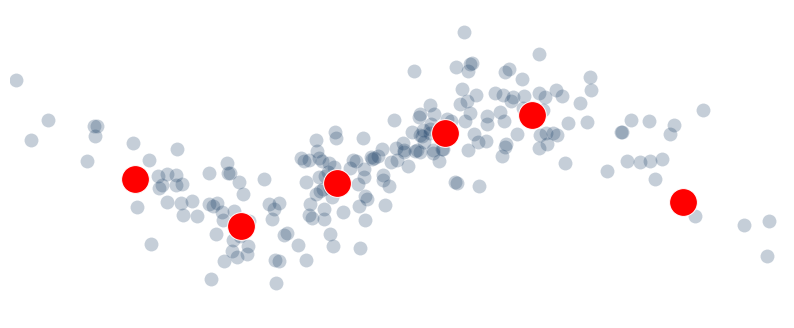

In [31]:
fig, ax = plt.subplots(figsize=(10, 4))

# Full dataset cloud
ax.scatter(pts[:, 0], pts[:, 1], s=100, c="#0d345e", alpha=0.24, linewidth=0, zorder=1)

# Coreset points
ax.scatter(sel[:, 0], sel[:, 1], s=400, c='red', edgecolor='white', linewidth=0.7, zorder=3)


ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_aspect('auto')

# Intentionally keep more margin so the visual mass appears smaller in slide boxes
qx0, qx1 = np.quantile(pts[:, 0], [0.02, 0.98])
qy0, qy1 = np.quantile(pts[:, 1], [0.02, 0.98])
mx = 0.14 * (qx1 - qx0)
my = 0.30 * (qy1 - qy0)
ax.set_xlim(qx0 - mx, qx1 + mx)
ax.set_ylim(qy0 - my, qy1 + my)

# Keep generous inner margins so the rendered figure fits slide color boxes
# ax.set_position([0.07, 0.16, 0.86, 0.68])
# 
out = Path('figures')
out.mkdir(parents=True, exist_ok=True)
# Avoid tight cropping; preserve canvas whitespace for safer slide embedding
fig.savefig(out / 'coreset_selection_illustration.pdf')
plt.show()